# Revised version of angular snapshot

In [19]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [20]:
# parameters used for the simulation (2d young sun)
r_env_init = 4.147678716913737E+10
r_tot = r_env_init / 0.44167
r_bot = 0.1 * r_tot
r_top = 0.97 * r_tot
Nr = 864
Ntheta = 270
# Nphi = 720
dr_grid = (r_top - r_bot) / Nr

In [21]:
PATTERN= "/z2/users/cj517/lscaledir_young_sun/r_min0.1_r_max0.97_2d/zerodir/*"
all_files = sorted(glob.glob(PATTERN))
all_files

['/z2/users/cj517/lscaledir_young_sun/r_min0.1_r_max0.97_2d/zerodir/zero.cont000000001',
 '/z2/users/cj517/lscaledir_young_sun/r_min0.1_r_max0.97_2d/zerodir/zero.cont000032400']

In [22]:
spec_file_idx = -1
spec_file = all_files[spec_file_idx]

In [23]:
def read_file(fname):
    with open(fname, 'r') as f:
        t = float(f.readline())
        df = pd.read_csv(f, sep='\s+',
                    #names=["num_theta", "theta_deg", "HP1", "r1", "renv", "HP2", "r21", "rcore"])
        #names=["num_theta", "theta_deg", "HP1", "r1", "renv", "HP2", "r21", "rcore", "renvdown", "renvup", "rcoredown", "rcoreup"])
        names=["num_phi", "phi_deg", "num_theta", "theta_deg", "HP1", "r1", "r2","r3","r4","r5", "HP2", "r21", "r22","r23","r24","r25"])
        df["time"] = t
        return df

In [24]:
df = pd.DataFrame(read_file(spec_file))
df = df.set_index(["num_theta"]).sort_index()
df

,num_phi,phi_deg,theta_deg,HP1,r1,r2,r3,r4,r5,HP2,r21,r22,r23,r24,r25,time
num_theta,,,,,,,,,,,,,,,,
1,1,45.2,45.2,1.696038e+10,4.139999e+10,4.102174e+10,4.139999e+10,4.102174e+10,4.102174e+10,0.0,9.532774e+09,9.532774e+09,9.532774e+09,9.532774e+09,9.532774e+09,161994900.0
2,2,45.5,45.5,1.696038e+10,4.139999e+10,4.102174e+10,4.139999e+10,4.102174e+10,4.102174e+10,0.0,9.532774e+09,9.532774e+09,9.532774e+09,9.532774e+09,9.532774e+09,161994900.0
3,3,45.8,45.8,1.696038e+10,3.884683e+10,4.139999e+10,3.884683e+10,4.139999e+10,4.139999e+10,0.0,9.532774e+09,9.532774e+09,9.532774e+09,9.532774e+09,9.532774e+09,161994900.0
4,4,46.2,46.2,1.696038e+10,3.884683e+10,4.139999e+10,3.884683e+10,4.139999e+10,4.139999e+10,0.0,9.532774e+09,9.532774e+09,9.532774e+09,9.532774e+09,9.532774e+09,161994900.0
5,5,46.5,46.5,1.696038e+10,3.884683e+10,4.139999e+10,3.884683e+10,4.139999e+10,4.139999e+10,0.0,9.532774e+09,9.532774e+09,9.532774e+09,9.532774e+09,9.532774e+09,161994900.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266,266,133.5,133.5,1.696035e+10,3.809034e+10,4.064350e+10,3.809034e+10,4.064350e+10,4.064350e+10,0.0,9.532774e+09,9.532774e+09,9.532774e+09,9.532774e+09,9.532774e+09,161994900.0
267,267,133.8,133.8,1.696036e+10,3.809034e+10,4.073806e+10,3.809034e+10,4.073806e+10,4.073806e+10,0.0,9.532774e+09,9.532774e+09,9.532774e+09,9.532774e+09,9.532774e+09,161994900.0
268,268,134.2,134.2,1.696036e+10,3.809034e+10,4.073806e+10,3.809034e+10,4.073806e+10,4.073806e+10,0.0,9.532774e+09,9.532774e+09,9.532774e+09,9.532774e+09,9.532774e+09,161994900.0


In [25]:
df['depth'] = (r_env_init - df['r1']) / r_tot

In [26]:
Hp_conv = df['HP1'].mean()

Text(0, 0.5, 'Penetration depth [$H_p$]')

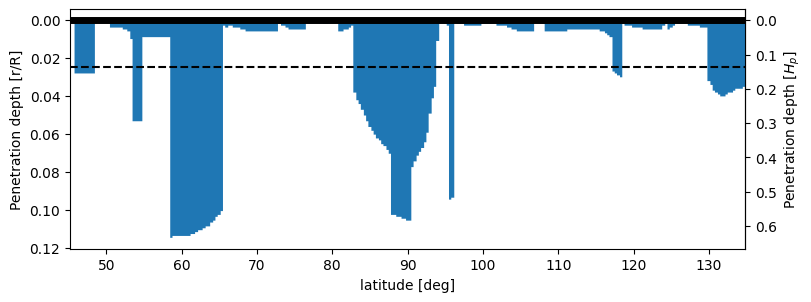

In [27]:
plt.rc("figure", figsize=(8, 8/2.75))
plt.rc("figure", dpi=100)
fig, ax = plt.subplots(layout='constrained')
ax.step(df['theta_deg'], df['depth'], where='post', label='Step plot', alpha=0)
ax.fill_between(df['theta_deg'], df['depth'], step='post', alpha=1)
# ax.set_ylim(0,0.01)
ax.set_xlim(df['theta_deg'].min(),df['theta_deg'].max())
fig.gca().invert_yaxis()
ax.axhline(y=0,color='k',linewidth=5)
ax.axhline(y=df['depth'].mean(),color='k',linestyle='--')



ax.set_xlabel(r'latitude [deg]')
ax.set_ylabel(r'Penetration depth [r/R]')
def P2R(P):
    return P * Hp_conv / r_tot

def R2P(R):
    return R * r_tot / Hp_conv

secax = ax.secondary_yaxis('right', functions=(R2P, P2R))
secax.set_ylabel(r'Penetration depth [$H_p$]')

# fig.savefig('angularsnapshot.svg')

In [28]:
import cj_plotter
from music_scripts.musicdata import MusicData

In [29]:
import os

# Absolute path you want to convert
absolute_path = "/home/cj517/z1_data/r_min0.1_r_max0.97_2d/base/params.nml"
# Get relative path from current working directory
relative_path = os.path.relpath(absolute_path)
print(relative_path)

../z1_data/r_min0.1_r_max0.97_2d/base/params.nml


In [30]:
sim = MusicData(relative_path)

In [31]:
sim._len

32451

In [32]:
r = sim[32400].grid.r_grid.cell_points()
t = sim[32400].grid.theta_grid.cell_points()

In [33]:
vel_1 = sim[32400].field['vel_1'].array()

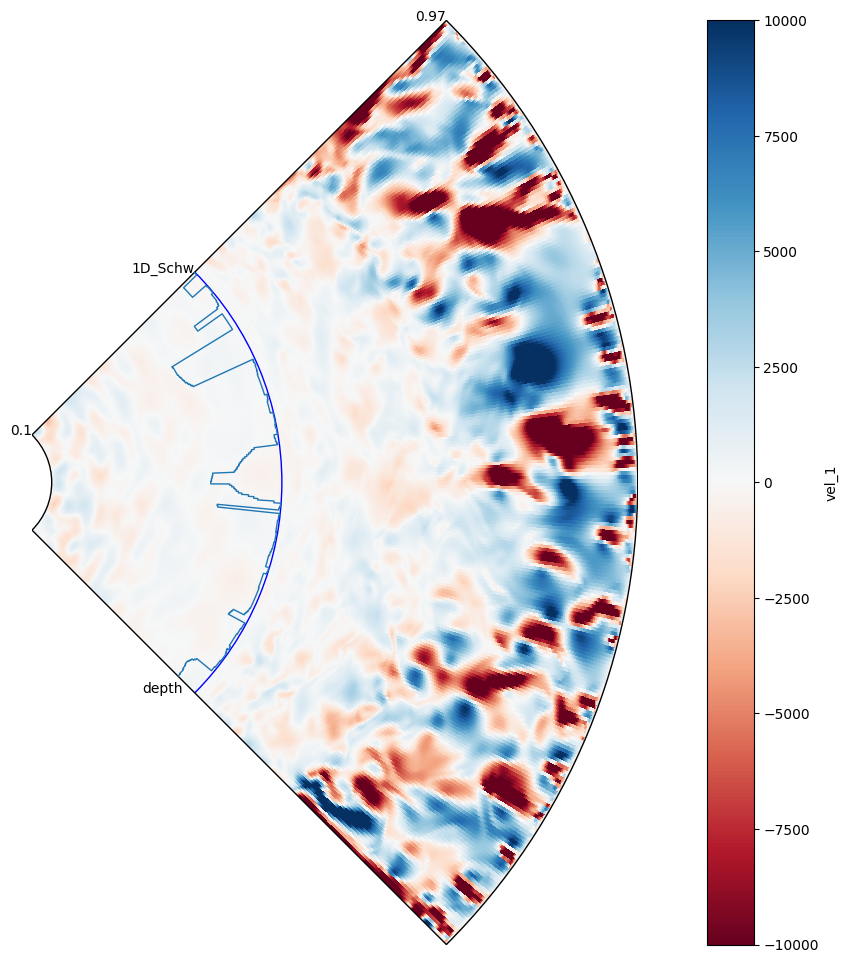

In [34]:
example_plot = cj_plotter.plot2D(t, r/r_tot, vel_1, -1e4, 1e4, cmap='RdBu') # , visible_ax=False)

example_plot.add_arc(r_env_init/r_tot, edgecolor='blue', label='1D_Schw')
example_plot.colorbar(label='vel_1')

example_plot.step(np.radians(df['theta_deg'].values), df['r1'].values / r_tot, linestyle='-', label='depth', label_position='bottom')

example_plot.savefig('young_sun_32400_ke_depth.png')

In [40]:
vel_2 = sim[32400].field['vel_2'].array()

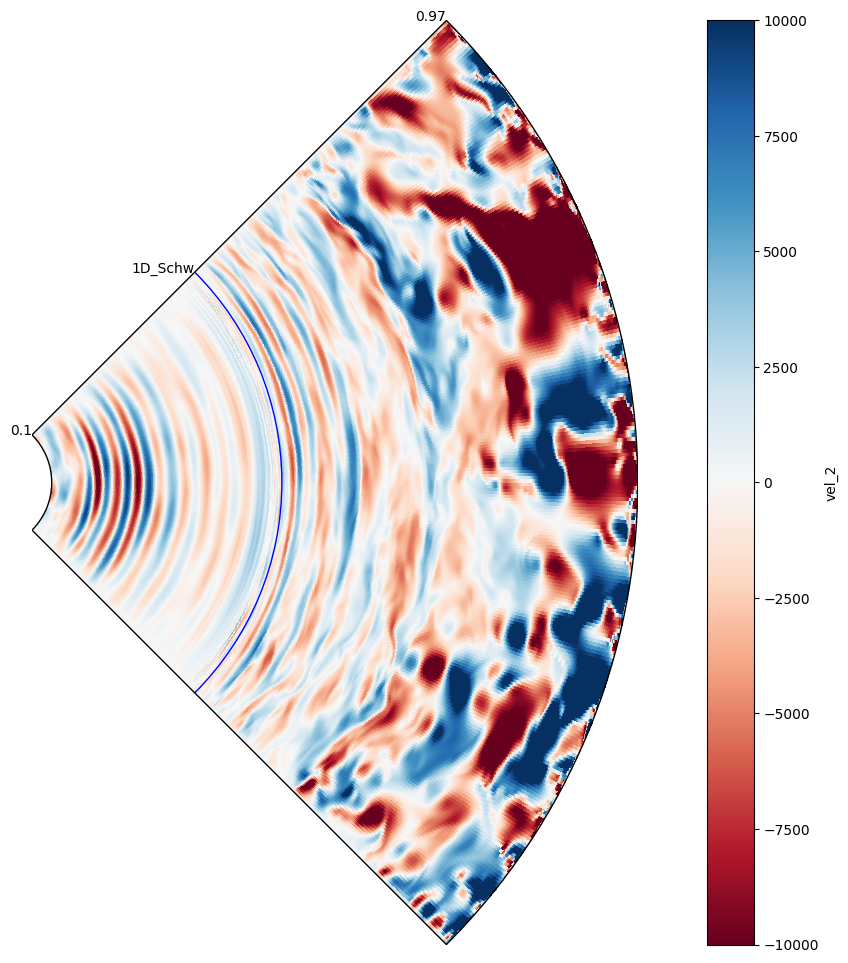

In [43]:
example_plot = cj_plotter.plot2D(t, r/r_tot, vel_2, -1e4, 1e4, cmap='RdBu') # , visible_ax=False)

example_plot.add_arc(r_env_init/r_tot, edgecolor='blue', label='1D_Schw')
example_plot.colorbar(label='vel_2')

# example_plot.step(np.radians(df['theta_deg'].values), df['r1'].values / r_tot, linestyle='-', label='depth', label_position='bottom')

example_plot.savefig('young_sun_32400_vel_2.png')